# Stats Overview
Recall we said that instances are sampled from the "universe of instances"

In stats, we say that a sample (of observations) comes from a population
* dataset = sample
* universe of instances = population

Example
* Population: all college students in the US
    * Expensive to collect data from in terms of time, resources, etc.
* Sample: students in CPSC 222
    * Inexpensive

Some more key stats terms
* Parameter: any measurable characteristc of a population
    * Example: $\mu$ population mean
* Statistic: any measureabkle characteristic of a sample
    * Example: $\overline{x}$ sample mean
* Descriptive stats: stats that organize and summarize data
    * Example: central tendency measures, data dispersion measures, etc.
* Inferential stats: stats that infer something above and beyond what is known from the data
    * Example: inferring something about the population based on a sample

## Summary Stats
Summarize a data distribution into a single value of a set of values. Examples:
* Number of data points
* Min and max
    * Do not make sense for nominal attributes

In [2]:
import pandas as pd

x = [6, 8, 3, 8, 8, 7]
ser = pd.Series(x)
print(ser)
print("Number of data points:", len(ser), ser.size, ser.shape)
print("Min:", ser.min(), "Max:", ser.max())
print(f"Median: {ser.median()}\tMean: {ser.mean()}\nMode: {ser.mode()}")

0    6
1    8
2    3
3    8
4    8
5    7
dtype: int64
Number of data points: 6 6 (6,)
Min: 3 Max: 8
Median: 7.5	Mean: 6.666666666666667
Mode: 0    8
dtype: int64


### Central Tendency
Measures the middle value(s) of a data distribution
* (Arithmetic) mean (AKA average)
    * Sensitive to outliers
    * Should only apply it when you know your data is numeric
* Median: middle value in a (sorted) list of numbers
* Mode: most frequently occurring value(s)
* Mid-value: $\frac{min + max}{2}$

TASK: calculate these measures with `ser`

### Data Dispersion (Spread)
Meaures how spread out the data are
* Range: max - min
* Quantiles
* Variance & standard deviation

Quantiles: divided (sorted) data into roughly equal sized partitions
* 2 quantiles: 1 data point that divides data into 2 halves (AKA median)
* Quartiles: 3 data points the divide data into 4 quarters
* Percentiles: 99 data points that divide data into 100 groups/partitions
    * 25th percentile (AKA 1st quartile)
    * 50th percentile (AKA 2nd quartile AKA median)
    * 75th percentile (AKA 3rd quartile)
* IQR (interquartile range): 3rd quartile - 1st quartile

Boxplots show percentile information in a nice data viz

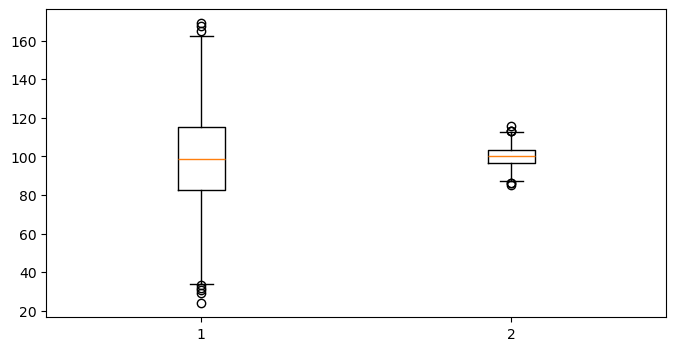

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# lets generate some random "normal" data
mean = 100
stdev = 25
num_samples = 1000
np.random.seed(0) # for reproducibility
x1 = np.random.normal(mean, stdev, num_samples)
x2 = np.random.normal(mean, stdev / 5, num_samples)

# horizontal line in the box: median
# the box itself: IQR
# the "whiskers" (lines) that extend from the box: 1.5 * IQR +/- 3rd & 1st quartile
# the circles are outliers
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html

plt.figure(figsize=(8, 4))
plt.boxplot([x1, x2])
plt.show()

Variance: measures how spread out data are from the mean
* Low variance: data are close to the mean
* High variance: data are quite spread out from the mean

More commonly, people use standard deviation because standard deviation is in the same units as the mean
* Standard deviation is the square root of variance
$$\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n}$$

variance: 3.866666666666667
stdev: 1.9663841605003503 1.9663841605003503


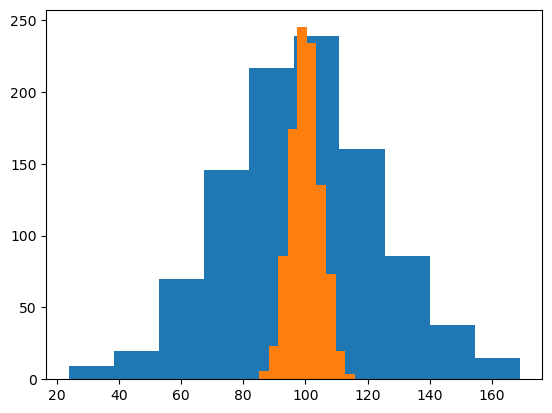

In [4]:
print("variance:", ser.var())
print("stdev:", ser.std(), np.sqrt(ser.var()))

# TASK: create a histogram with both x1 and x2 data
# make a prediction about the shape of each data's histogram
plt.figure()
plt.hist(x1)
plt.hist(x2)
plt.show()

## Empirical Rule for Normal Distributions
* (about) 68% of the data lies within mean +/- 1 standard deviation
* (about) 95% of the data lies within mean +/- 2 standard deviation
* (about) 99.7% of the data lies within mean +/- 3 standard deviation

In [5]:
# task: "prove" the empirical rule applies to our x1 data
count_within1_stdev = 0
count_within2_stdev = 0
count_within3_stdev = 0

sample_mean = np.mean(x1)
sample_stdev = np.std(x1)

for value in x1:
    if sample_mean - 1 * sample_stdev <= value <= sample_mean + 1 * sample_stdev:
        count_within1_stdev += 1
    if sample_mean - 2 * sample_stdev <= value <= sample_mean + 2 * sample_stdev:
        count_within2_stdev += 1
    if sample_mean - 3 * sample_stdev <= value <= sample_mean + 3 * sample_stdev:
        count_within3_stdev += 1

print(f"within +/- 1: {count_within1_stdev / num_samples * 100}%")
print(f"within +/- 2: {count_within2_stdev / num_samples * 100}%")
print(f"within +/- 3: {count_within3_stdev / num_samples * 100}%")

within +/- 1: 68.8%
within +/- 2: 95.0%
within +/- 3: 99.9%
